# 以 ollama 串接 langchain 執行 llama3-8b

In [6]:
# 設定必要的資源包和函式
# %pip install langchain chromadb pypdf fastembed
# %pip install aiofiles
# %pip install langchain_google_genai
# %pip install langchain_community

In [7]:
import os
from IPython.display import display
from IPython.display import Markdown
from datetime import datetime
import numpy_financial as npf
import math
import pandas as pd
import numpy
import json

from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import FastEmbedEmbeddings
from langchain.schema.output_parser import StrOutputParser
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema.runnable import RunnablePassthrough
from langchain.prompts import PromptTemplate
from langchain.vectorstores.utils import filter_complex_metadata
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

# 設定模型參數

In [8]:
model = 'gemini-1.5-flash'
temperature = 1
top_p = 0.9
seed = 0
chunk_size=1024
chunk_overlap=10
# os.environ["GOOGLE_API_KEY"] = os.getenv('GEMINI_API_KEY')

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
            })

# RAG

In [9]:
# 用來讀取文字檔，並轉成 embedding
from typing import AsyncIterator, Iterator

from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document


class CustomDocumentLoader(BaseLoader):
    """An example document loader that reads a file line by line."""

    def __init__(self, file_path: str) -> None:
        """Initialize the loader with a file path.

        Args:
            file_path: The path to the file to load.
        """
        self.file_path = file_path

    def lazy_load(self) -> Iterator[Document]:  # <-- Does not take any arguments
        """A lazy loader that reads a file line by line.

        When you're implementing lazy load methods, you should use a generator
        to yield documents one by one.
        """
        with open(self.file_path, encoding="utf-8") as f:
            line_number = 0
            for line in f:
                yield Document(
                    page_content=line,
                    metadata={"line_number": line_number, "source": self.file_path},
                )
                line_number += 1

    # alazy_load is OPTIONAL.
    # If you leave out the implementation, a default implementation which delegates to lazy_load will be used!
    async def alazy_load(
        self,
    ) -> AsyncIterator[Document]:  # <-- Does not take any arguments
        """An async lazy loader that reads a file line by line."""
        # Requires aiofiles
        # Install with `pip install aiofiles`
        # https://github.com/Tinche/aiofiles
        import aiofiles

        async with aiofiles.open(self.file_path, encoding="utf-8") as f:
            line_number = 0
            async for line in f:
                yield Document(
                    page_content=line,
                    metadata={"line_number": line_number, "source": self.file_path},
                )
                line_number += 1


In [10]:
# RAG
class RAG:
    vector_store = None
    retriever = None
    chain = None

    def __init__(self):
        self.model = llm
        self.text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
        self.prompt = PromptTemplate.from_template(
            """
            <s> [INST] 以下是今天的新聞資訊，請對於明天開盤時買進收盤時賣出的獲利可能性進行判斷，如果可以獲利請回答#好 否則#不好 如果與股市無關則回答#無關 [/INST] </s> 
            [INST] 問題: {question} 
            文章: {context} 
            回答: [/INST]
            """
        )

    def ingest(self, pdf_file_path: str):
        docs = CustomDocumentLoader(file_path=pdf_file_path).load()
        chunks = self.text_splitter.split_documents(docs)
        chunks = filter_complex_metadata(chunks)
        # chunks.append(chunks)

        vector_store = Chroma.from_documents(documents=chunks, embedding=FastEmbedEmbeddings())
        self.retriever = vector_store.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs={
                "k": 3,
                "score_threshold": 0.5,
            },
        )

        self.chain = ({"context": self.retriever, "question": RunnablePassthrough()}
                      | self.prompt
                      | self.model
                      | StrOutputParser())

    def ask(self, query: str):
        if not self.chain:
            return "Please, add a document first."

        return self.chain.invoke(query)

    def clear(self):
        self.vector_store = None
        self.retriever = None
        self.chain = None


In [11]:
# 測試rag是否能夠正常運行
# import os

# rag = RAG()
# rag.clear()
# rag.ingest(os.path.dirname(os.path.abspath(os.getcwd()))  + "/stock_news/3023/3023_news/20050129")

# # response = rag.ask(f"請對{stock_id} {stock_names[idx]}的新聞對的隔日開盤買進收盤賣出進行判斷，如果可以獲利請回答#好 否則#不好 如果新聞內容與股市無關則回答#無關")
# response = rag.ask(f"請找出對3023信邦的股價有影響的新聞資料")

# print(response)

In [12]:
# rag 回應
def rag_response(ragfile, instruction):
    '''
        ragfile: string 檔案路徑
        instruction: string 問題指令
        
        return: string 回答
    '''
    text = ''
    try:
        rag = RAG()
        rag.clear()
        rag.ingest(ragfile)
        text = rag.ask(instruction)
        # print(text)
    except Exception as e:
        print(e)
        pass
    return text

In [13]:
def llm_response(filepath, question):
    ''' 
        filepath: string 檔案路徑
        question: string 問題指令
        
        return: string 回答
    '''
    with open(filepath, 'r', encoding='utf-8') as f:
        news = f.read()

    prompt = f"""<s> [INST] 以下是今天的新聞資訊，請對於明天開盤時買進收盤時賣出的獲利可能性進行判斷，如果可以獲利請回答#好 否則#不好 如果與股市無關則回答#無關 [/INST] </s> 
            [INST] 問題: {question} 
            文章: {news} 
            回答: [/INST]
            """

    try:
        response = llm.invoke(prompt)
        # print(text)
        return response.content
    except Exception as e:
        print(e)
        pass
    
    return "無關"
    

In [14]:
# 轉換回答變成訊號
def response_to_signal(text):
    '''
        text: string 回答訊息
        
        return: int 回答訊號
    '''
    if text.find('不好') > 0:
        signal = -1
    elif text.find('好') > 0:
        signal = 1
    else:
        signal = 0

    return signal

In [15]:
# 計算隔天當沖準確率（開盤買進收盤賣出or開盤賣出收盤回補）
def eval(signal_l, price):
    '''
        signal: list, [日期, 評分]
        price: dataframe, 股票價格

        return: float, float 準確率, 平均報酬率
    '''
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    rtns = []   # 記錄當日沖銷的報酬率

    for idx, item in enumerate(signal_l):
        signal = float(item[1])
        index_location = price.index.get_loc(item[0])  # 獲取特定索引的位置
        if index_location == len(price.index) - 1: # 避免超出索引
            break
        next_index = price.index[index_location + 1]  # 獲取下一個索引的位置
        next_row = price.loc[next_index]  # 找到下一個索引的列
        open = float(next_row['Open'])
        close = float(next_row['Close'])
        
        if signal > 0:
            rtns.append(close/open)
            if close > open:
                tp += 1
            elif close < open:
                fp += 1
            else:   
                pass

        elif signal < 0:
            rtns.append(open/close)
            if close < open:
                tn += 1
            elif close > open:
                fn += 1
            else:   
                pass
    if (tp + tn + fp + fn)  == 0:
        accuracy = 0
    else:
        accuracy = (tp + tn) / (tp + tn + fp + fn) # 準確率
        print(tp, tn, fp, fn)

    if len(rtns) == 0:
        avg_rtn = 1.0
    else:
        avg_rtn = sum(rtns)/len(rtns)  # 這檔股票在這段時間的平均報酬率
        print(avg_rtn)
    return accuracy, avg_rtn

In [16]:
def write_output(content, folder_path):
    '''
        json_content: string, json格式的資料
        raw_data: list, 評分的資料
        folder_path: string, 資料夾路徑
    '''
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    with open(folder_path + "detail.json" , "w", encoding="UTF-8") as f:
        f.write(content)
    print("寫入" + folder_path)

# RAG主程式

In [7]:
# 上市公司股票代號
# 代號 ['2618', '2881', '2880', '2211', '2731', '2707', '3023', '9941', '2308', '1514', '1101', '2542', '3036', '2385', '1303', '2912', '2323', '2603', '1419', '1604', '2486', '5269', '1314', '8033', '3017', '2903', '9943', '2368', '9904', '1102', '3231', '3004', '3035', '6176', '1103', '2609', '2002']
# 對應名稱 ['長榮航', '富邦金', '華南金', '長榮鋼', '雄獅', '晶華', '信邦', '裕融', '台達電', '亞力', '台泥', '興富發', '文曄', '群光', '南亞', '統一超', '中環', '長榮', '新光金', '聲寶', '一詮', '祥碩', '中石化', '遠雄', '奇鋐', '遠百', '好樂迪', '金像電', '寶成', '亞泥', '緯創', '豐達科', '智原', '瑞儀', '嘉泥', '陽明', '中鋼']
from datetime import datetime

start_time = datetime(2023, 1, 1)
end_time = datetime(2023, 12, 31)

stock_ids = ['2618', '2881', '2880', '2211', '2731', '2707', '3023', '9941', '2308', '1514']
stock_names = ['長榮航', '富邦金', '華南金', '長榮鋼', '雄獅', '晶華', '信邦', '裕融', '台達電', '亞力']

In [ ]:
# count = 0
for idx, stock_id in enumerate(stock_ids):

    folder_path = os.path.dirname(os.path.abspath(os.getcwd())) + "/stock_news/" + stock_id + "/" + stock_id + "_news/"
    sorted_news_files = sorted(os.listdir(folder_path))

    # 載入價格資料
    df_price = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + stock_id + "twse.csv", dtype=str)
    df_price.set_index('Date', inplace=True)  # 將'Date'行設置為索引
    
    acc_ = 0
    print(f'正在執行{stock_id} {stock_names[idx]}')
    qurey = f"請找出對{stock_id}{stock_names[idx]}的股價有影響的新聞資料"
    signal = []
    counter = 0
    for date in df_price.index:
        # 檢查日期是否在參考日期之後
        try:
            date_obj = datetime.strptime(date, '%Y%m%d')
        except:
            continue

        if not (start_time <= date_obj <= end_time):
            continue
        
        sig = 0
        for index, file_name in enumerate(sorted_news_files):
            if file_name == date:
                res = rag_response(folder_path + file_name, qurey)   # file_name, qurey
                sig = response_to_signal(res)    # file_name, qurey
                # count += 1
                break
        signal.append([date, sig]) # [日期, 訊號]
        print(f'{date}: {sig}')

    acc, rtn = eval(signal, df_price) # 得到這檔股票的準確率和報酬率

    # 輸出結果 json file
    output_data = {
        "date_start": start_time.strftime("%Y%m%d"),
        "date_end": end_time.strftime("%Y%m%d"),
        "acc": acc,
        "rtn": rtn,
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
        "raw_data": signal
    }

    # 轉換成 JSON 格式
    json_content = json.dumps(output_data, ensure_ascii=False, indent=4)
    write_output(content=json_content, folder_path="eval_rag/output052801rag/" + stock_id + "/")
# print(count)

# 沒有RAG 當作對照組

In [ ]:
llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY_2'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
            })
for idx, stock_id in enumerate(stock_ids):

    folder_path = os.path.dirname(os.path.abspath(os.getcwd())) + "/stock_news/" + stock_id + "/" + stock_id + "_news/"
    sorted_news_files = sorted(os.listdir(folder_path))

    # 載入價格資料
    df_price = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + stock_id + "twse.csv", dtype=str)
    df_price.set_index('Date', inplace=True)  # 將'Date'行設置為索引
    
    acc_ = 0
    print(f'正在執行{stock_id} {stock_names[idx]}')
    prompt = f"請找出對{stock_id}{stock_names[idx]}的股價有影響的新聞資料"
    signal = []
    counter = 0
    for date in df_price.index:
        # 檢查日期是否在參考日期之後
        try:
            date_obj = datetime.strptime(date, '%Y%m%d')
        except:
            continue

        if not (start_time <= date_obj <= end_time):
            continue
        
        sig = 0
        for index, file_name in enumerate(sorted_news_files):
            if file_name == date:
                res = llm_response(folder_path + file_name, prompt)
                print(res)
                sig = response_to_signal(res) 
                break
        
        signal.append([date, sig]) # [日期, 訊號]
        print(f'{date}: {sig}')

    acc, rtn = eval(signal, df_price) # 得到這檔股票的準確率和報酬率

    # 輸出結果 json file
    output_data = {
        "date_start": start_time.strftime("%Y%m%d"),
        "date_end": end_time.strftime("%Y%m%d"),
        "acc": acc,
        "rtn": rtn,
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "raw_data": signal
    }

    # 轉換成 JSON 格式
    json_content = json.dumps(output_data, ensure_ascii=False, indent=4)
    write_output(content=json_content, folder_path="eval_rag/output_norag052801/" + stock_id + "/")

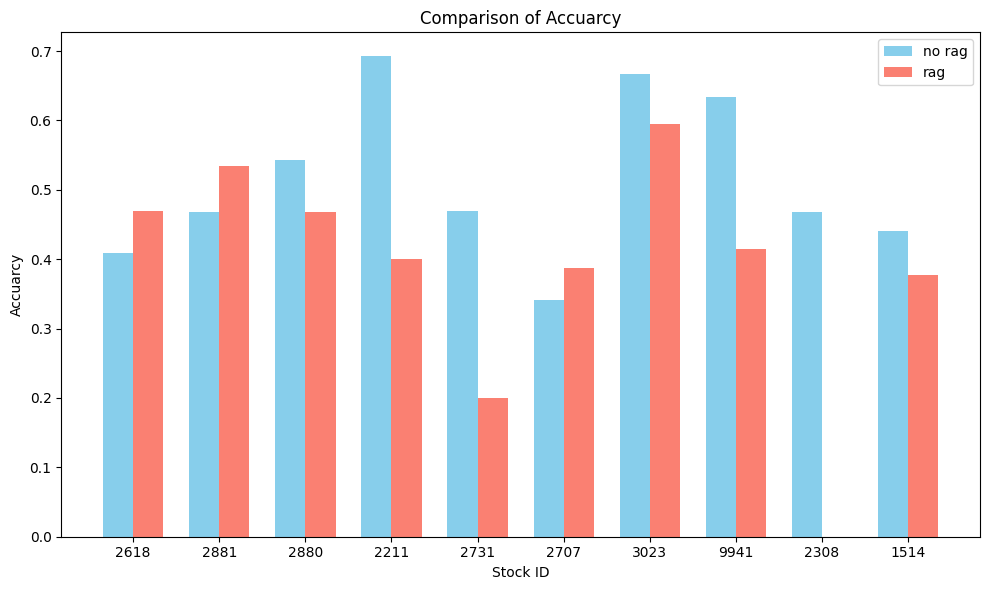

In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np

acc_1 = []
acc_2 = []
for idx, stock_id in enumerate(stock_ids):
    with open("eval_rag/output_norag052801/" + stock_id + "/detail.json") as f:
        data = json.load(f)
        acc_1.append(data['acc'])

    with open("eval_rag/output052801rag/" + stock_id + "/detail.json") as f:
        data = json.load(f)
        acc_2.append(data['acc'])

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, acc_1, width, label='no rag', color='skyblue')
bars2 = ax.bar(x + width/2, acc_2, width, label='rag', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()
